In [12]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src.features import make_features, make_targets, attach_store_data
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

N_STORES = 3
DAYS     = 500
FORECAST_HORIZON = 15

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)

def make_synthetic_sales_data():
    dates    = pd.date_range("2013-01-01", periods=DAYS, freq="D")
    rows = []
    rng  = np.random.default_rng(C.SEED)
    for store_id in range(1, N_STORES + 1):
        base = 300 + store_id * 150          # stores differ in overall level
        for date in dates:
            dow      = date.dayofweek + 1    # 1=Mon … 7=Sun
            is_sun   = dow == 7
            seasonal = base + 20 * np.sin(2 * np.pi * (dow - 1) / 6)   # peak Wed
            trend    = 0.15 * (date - dates[0]).days
            promo    = int(rng.random() < 0.25)
            sales    = max(0.0, seasonal + trend + promo * 100) if not is_sun else 0.0
            rows.append({
                "Date":          date,
                "Store":         store_id,
                "DayOfWeek":     dow,
                "Open":          0 if is_sun else 1,
                "Promo":         promo,
                "StateHoliday":  "0",
                "SchoolHoliday": 0,
                "Sales":         sales,
            })

    train = pd.DataFrame(rows)

    return train

def make_synthetic_store_data():

    stores = pd.DataFrame({
        "Store":               list(range(1, N_STORES + 1)),
        "StoreType":           ["a", "b", "c"],
        "Assortment":          ["a", "a", "b"],
        "CompetitionDistance": [500.0, 1200.0, 800.0],
        "CompetitionSinceDate": pd.to_datetime(["2012-03-01", "2011-06-01", "2013-01-01"]),
        "Promo2SinceDate":     pd.to_datetime(["2012-06-01", pd.NaT,       "2013-03-01"]),
        "PromoInterval":       ["Jan,Apr,Jul,Oct", None,                   "Mar,Jun,Sep,Dec"],
    })

    return stores


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate  Promo2
         2     1      0            0              0 467.320508         a          a                500.0           2012-03-01      2012-06-01       1
         3     1      0            0              0 467.470508         a          a                500.0           2012-03-01      2012-06-01       1
         4     1      0            0              0 450.300000         a          a                500.0           2012-03-01      2012-06-01       1
         5     1      0            0              0 433.129492         a          a                500.0           2012-03-01      2012-06-01       1
         6     1      1            0              0 533.279492         a          a                500.0           2012-03-01      2012-06-01       1


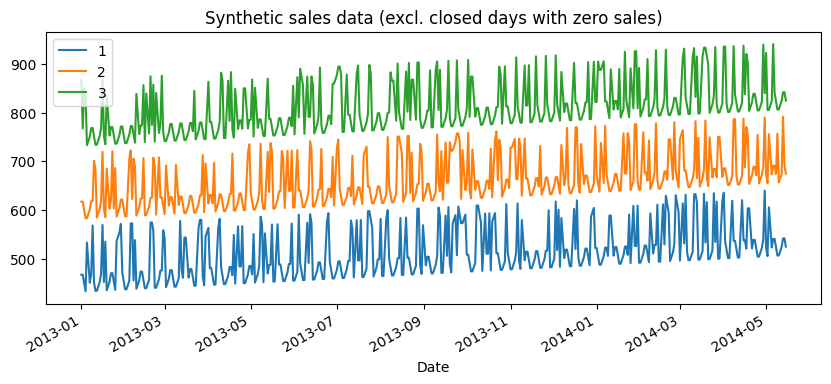

In [13]:
stores = make_synthetic_store_data()
train = make_synthetic_sales_data()
df  = attach_store_data(train, stores).set_index(["Date", "Store"])

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "inner_train_size": 80, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [3]:

# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. Log-transform the target
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)
df_processed = df.copy()
df_processed['Sales'] = utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate').apply(np.log1p)
X = make_features(df_processed, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
y = make_targets(df_processed['Sales'], C.FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break


[0]	train-rmse:0.17780+0.00158	test-rmse:0.19127+0.00150
[0]	train-rmse:0.15275+0.00079	test-rmse:0.18204+0.00089
[0]	train-rmse:0.19053+0.00197	test-rmse:0.19681+0.00210
[0]	train-rmse:0.19297+0.00202	test-rmse:0.19791+0.00221
[25]	train-rmse:0.06758+0.00242	test-rmse:0.17231+0.00418
[0]	train-rmse:0.19321+0.00202	test-rmse:0.19802+0.00222
[62]	train-rmse:0.06808+0.00246	test-rmse:0.12576+0.00331
[0]	train-rmse:0.19210+0.00200	test-rmse:0.19751+0.00217
[45]	train-rmse:0.08410+0.00100	test-rmse:0.16781+0.00352
[0]	train-rmse:0.19157+0.00197	test-rmse:0.19727+0.00214
[58]	train-rmse:0.09192+0.00102	test-rmse:0.15795+0.00317
[0]	train-rmse:0.19319+0.00201	test-rmse:0.19796+0.00222
[100]	train-rmse:0.08867+0.00131	test-rmse:0.14539+0.00322
[73]	train-rmse:0.07683+0.00194	test-rmse:0.15431+0.00403
[0]	train-rmse:0.19244+0.00199	test-rmse:0.19767+0.00219
[0]	train-rmse:0.18897+0.00193	test-rmse:0.19608+0.00202
[0]	train-rmse:0.19305+0.00201	test-rmse:0.19794+0.00221
[0]	train-rmse:0.17309+0

In [20]:
booster_file_1 = f"C:\\Users\\m_kal\\Downloads\\rossmann_store_sales\\artifacts\\fold_1\\trial_{study.best_trial.number:04d}\\fold_3.ubj"
booster_file_2 = os.path.join(study_config["log_dir"], study_name, "model.ubj")

for booster_file in [booster_file_1, booster_file_2]:

    booster = xgb.Booster()
    booster.load_model(booster_file)
    preds = utils.predict(booster, X_test)

    actuals_idx = preds.index.droplevel("Date").swaplevel()  # (Forecast Date, Store)
    true_vals = df.loc[actuals_idx, "Sales"]

    m = compute_metrics(true_vals.values, preds.values)
    print(f"Metrics for {booster_file}: {m}")

Metrics for C:\Users\m_kal\Downloads\rossmann_store_sales\artifacts\fold_1\trial_0000\fold_3.ubj: {'MAE': 55.488, 'RMSE': 74.111, 'MAPE': 10.273, 'RMSPE': 12.865}
Metrics for ./artifacts\fold_1\model.ubj: {'MAE': 54.401, 'RMSE': 73.272, 'MAPE': 10.056, 'RMSPE': 12.636}


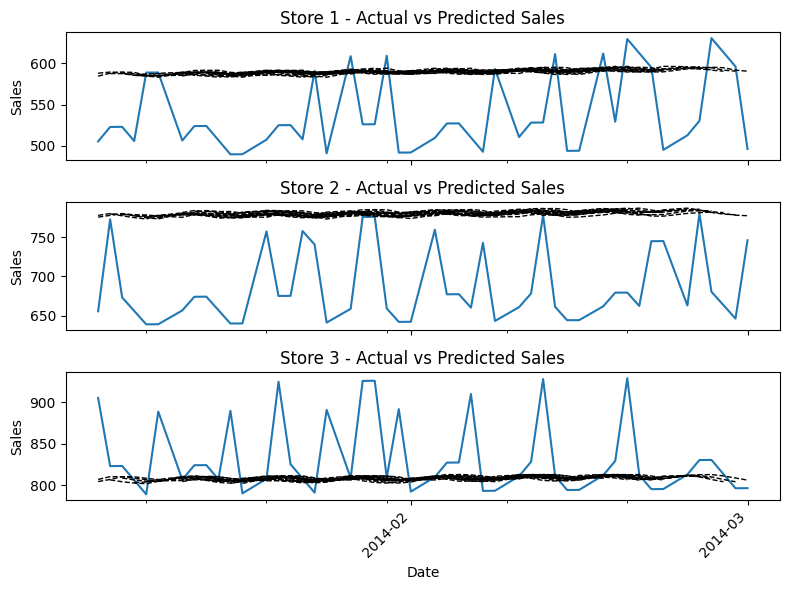

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


stores = df.index.get_level_values("Store").unique()
fig, ax = plt.subplots(figsize=(8, 6), nrows=len(stores), sharex=True, sharey=False)


for i, store in enumerate(stores):

    actual_store_sales = (utils.retrieve_sales(df['Sales'], preds.index)
                          .loc[(slice(None), store)]
                          .sort_index())
    
    predicted_store_sales = (preds
                             .loc[(slice(None), store, slice(None))]
                             .reset_index())

    # exclude closed days with zero sales and zero predictions
    actual_store_sales = actual_store_sales[actual_store_sales > 0]
    predicted_store_sales = predicted_store_sales[predicted_store_sales["value"] > 0]

    actual_store_sales.plot(label=f"Store {store}", ax=ax[i])
    (predicted_store_sales
    .groupby("Date")
    .plot(x="Forecast Date", y="value", ax=ax[i], color='k', linestyle='--', linewidth=1))

    ax[i].get_legend().remove()
    ax[i].set_title(f"Store {store} - Actual vs Predicted Sales")
    ax[i].set_ylabel("Sales")
    
# Rotate x labels and set date format
ax[-1].xaxis.set_major_locator(mdates.MonthLocator())
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()